# Deep Learning: Assignment #4
## Submission date: 28/01/2026, 23:59.
### Topics:
- Word Embeddings
- Transformers
- Vision Transformers
- Few-Shot Learning
- Self-Supervised Learning


**Submitted by:**

- **Student 1 — Aisha Abu Dahesh**
- **Student 2 — Yosef Asadi**


**Assignment Instructions:**

· Submissions are in **pairs only**. Write both names + IDs at the top of the notebook.

· Keep your code **clean, concise, and readable**.

· You may work in your IDE, but you **must** paste the final code back into the **matching notebook cells** and run it there.  


· <font color='red'>Write your textual answers in red.</font>  
(e.g., `<span style="color:red">your answer here</span>`)

· All figures, printed results, and outputs should remain visible in the notebook.  
Run **all cells** before submitting and **do not clear outputs**.

· Use relative paths — **no absolute file paths** pointing to local machines.

· **Important:** Your submission must be entirely your own.  
Any form of plagiarism (including uncredited use of ChatGPT or AI tools) will result in **grade 0** and disciplinary action.


In [1]:
# Global Setup

import os
import re
import math
import random
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Question 1: Learning Vision–Language Representations with Transformers (60 Points)

Recent multimodal models have shown that images and natural language can be embedded into a **shared semantic space**, enabling tasks such as image–text retrieval and zero-shot inference without training task-specific classifiers.

In this question, you will build a simplified multimodal model inspired by CLIP, combining a **Vision Transformer (ViT)** image encoder with a **Transformer-based text encoder**, trained using a **contrastive objective**.



### Load & Preprocess Data

In this homework, we use the **Flickr8k dataset**, a small-scale vision–language dataset commonly used in image captioning and multimodal learning research.

The dataset contains:
- approximately 8,000 natural images,
- five human-written captions per image.

Each training example consists of an image paired with one of its captions.  
Throughout this assignment, images and captions will be used to learn a **shared embedding space** between vision and language.

You may use the following commands to download and extract the dataset into your working directory:


In [2]:
!wget "https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip"
!unzip -q flickr8k.zip -d ./flickr8k

--2026-02-28 16:26:38--  https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/753516996/d7c62b13-1e50-40ea-8fae-f34a44b1695f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-28T17%3A02%3A49Z&rscd=attachment%3B+filename%3Dflickr8k.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-28T16%3A02%3A03Z&ske=2026-02-28T17%3A02%3A49Z&sks=b&skv=2018-11-09&sig=MMvlPFO4jmy6rVazPqvVHxBMUBHi%2BHe28Bh%2Bjx2ocs0%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MjI5OTU5OCwibmJmIjoxNzcyMjk1OTk4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5

In [3]:
# unzip data
!unzip -q /content/flickr8k.zip -d /content/

Before training any models, the raw images and captions must be preprocessed into a form suitable for Transformer-based models.

Your preprocessing pipeline should include:
- loading and transforming images into tensors of a fixed size,
- parsing the captions file and associating each image with its captions,
- basic text preprocessing (e.g., lowercasing and tokenization),
- converting captions into sequences of token indices,
- creating attention masks for padded tokens.

You are free to choose reasonable design decisions (e.g., maximum caption length, tokenization strategy), as long as they are applied **consistently** throughout the assignment.


In [4]:
# TODO: Implement


ROOT = "/content/flickr8k"
IMG_DIR = os.path.join(ROOT, "Images")
CAPTIONS_FILE = os.path.join(ROOT, "captions.txt")

# tokens and settings
PAD, UNK, BOS, EOS = "<pad>", "<unk>", "<bos>", "<eos>"
MIN_FREQ = 2
MAX_LEN = 32          # max caption tokens (excluding BOS/EOS)
IMG_SIZE = 224

# simple tokenizer (lowercase, capture words and numbers)
_token_re = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?", re.IGNORECASE)

# Return list of tokens from text (lowercased)
def tokenize(text: str) -> List[str]:
    return _token_re.findall(text.lower().strip())

def caption_to_ids(caption: str,
                   stoi: Dict[str, int],
                   unk_id: int,
                   bos_id: int,
                   eos_id: int,
                   max_len: int = MAX_LEN) -> List[int]:
    toks = tokenize(caption)
    toks = toks[: max_len - 2]  # reserve space for BOS/EOS
    return [bos_id] + [stoi.get(t, unk_id) for t in toks] + [eos_id]

# Load an image from path and convert to RGB PIL image
def pil_loader(path: str) -> Image.Image:
    with open(path, "rb") as f:
        img = Image.open(f)
        return img.convert("RGB")

# Dataset / Collate
class Flickr8kDataset(Dataset):
    def __init__(self,
                 image_list: List[str],
                 captions_map: Dict[str, List[str]],
                 img_dir: str,
                 transform=None,
                 sample_one_caption: bool = True,
                 stoi: Optional[Dict[str, int]] = None,
                 unk_id: Optional[int] = None,
                 bos_id: Optional[int] = None,
                 eos_id: Optional[int] = None):
        self.image_list = image_list
        self.captions_map = captions_map
        self.img_dir = img_dir
        self.transform = transform
        self.sample_one_caption = sample_one_caption

        # token mapping info
        self.stoi = stoi
        self.unk_id = unk_id
        self.bos_id = bos_id
        self.eos_id = eos_id

        # build pairs list (img, cap) or (img, None) depending on sampling strategy
        self.pairs = []
        for img in self.image_list:
            caps = self.captions_map.get(img, [])
            if not caps:
                continue
            if sample_one_caption:
                self.pairs.append((img, None))
            else:
                for cap in caps:
                    self.pairs.append((img, cap))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, fixed_cap = self.pairs[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = pil_loader(img_path)
        if self.transform is not None:
            image = self.transform(image)

        cap = random.choice(self.captions_map[img_name]) if fixed_cap is None else fixed_cap
        if self.stoi is None:
            raise ValueError("stoi (vocabulary mapping) must be provided to dataset")
        cap_ids = caption_to_ids(cap, self.stoi, self.unk_id, self.bos_id, self.eos_id)

        return {
            "image": image,
            "caption_ids": torch.tensor(cap_ids, dtype=torch.long),
            "image_name": img_name,
            "raw_caption": cap,
        }

# Batch images and pad captions; produce attention mask (True for token, False for pad)
def collate_fn(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)

    cap_seqs = [b["caption_ids"] for b in batch]
    lengths = torch.tensor([len(x) for x in cap_seqs], dtype=torch.long)

    maxL = int(lengths.max().item())
    caps_padded = torch.full((len(batch), maxL), fill_value=pad_id, dtype=torch.long)

    for i, seq in enumerate(cap_seqs):
        caps_padded[i, :len(seq)] = seq

    attention_mask = (caps_padded != pad_id)

    return {
        "images": images,
        "captions": caps_padded,
        "attention_mask": attention_mask,
        "lengths": lengths,
        "image_name": [b["image_name"] for b in batch],
        "raw_caption": [b["raw_caption"] for b in batch],
    }

train_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), interpolation=InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# load captions, build vocab, create loaders
def prepare_loaders(root: str = ROOT,
                    img_dir: str = IMG_DIR,
                    captions_file: str = CAPTIONS_FILE,
                    batch_size: int = 128,
                    num_workers: int = 2,
                    seed: int = 42):

    # sanity checks for paths
    assert os.path.exists(img_dir), f"Image dir not found: {img_dir}"
    assert os.path.exists(captions_file), f"Captions file not found: {captions_file}"

    # collect image files
    all_images = sorted([p for p in os.listdir(img_dir) if p.lower().endswith((".jpg", ".jpeg", ".png"))])

    # parse captions file into mapping {image_name -> [captions]}
    captions_by_image: Dict[str, List[str]] = defaultdict(list)
    with open(captions_file, "r", encoding="utf-8") as f:
        header = f.readline().strip().lower()
        # treat first line as header only if it contains both "image" and "caption"
        if not ("image" in header and "caption" in header):
            f.seek(0)

        for line in f:
            line = line.strip()
            if not line:
                continue

            # split on first comma
            if "," in line:
                img_name, cap = line.split(",", 1)
            else:
                parts = line.split("\t")
                if len(parts) >= 2:
                    img_name, cap = parts[0], parts[1]
                else:
                    continue

            img_name = img_name.strip()
            cap = cap.strip()
            if img_name in all_images and cap:
                captions_by_image[img_name].append(cap)

    # keep only images that have captions
    image_list = [im for im in all_images if im in captions_by_image]

    # split train and validation
    random.seed(seed)
    random.shuffle(image_list)
    n = len(image_list)
    n_train = int(0.8 * n)

    train_images = image_list[:n_train]
    val_images   = image_list[n_train:]
    test_images  = []

    # build vocab from training captions (min frequency filter)
    counter = Counter()
    for img in train_images:
        for cap in captions_by_image[img]:
            counter.update(tokenize(cap))

    # deterministic ordering
    sorted_tokens = sorted([(w, c) for w, c in counter.items() if c >= MIN_FREQ],
                           key=lambda x: (-x[1], x[0]))

    vocab = [PAD, UNK, BOS, EOS] + [w for w, c in sorted_tokens]
    stoi = {w: i for i, w in enumerate(vocab)}
    itos = {i: w for w, i in stoi.items()}

    global pad_id, unk_id, bos_id, eos_id
    pad_id = stoi[PAD]
    unk_id = stoi[UNK]
    bos_id = stoi[BOS]
    eos_id = stoi[EOS]

    # create datasets and dataloaders
    train_ds = Flickr8kDataset(train_images, captions_by_image, img_dir,
                               transform=train_transform, sample_one_caption=True,
                               stoi=stoi, unk_id=unk_id, bos_id=bos_id, eos_id=eos_id)

    val_ds = Flickr8kDataset(val_images, captions_by_image, img_dir,
                             transform=val_transform, sample_one_caption=True,
                             stoi=stoi, unk_id=unk_id, bos_id=bos_id, eos_id=eos_id)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, collate_fn=collate_fn)

    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True, collate_fn=collate_fn)

    print(f"train imgs: {len(train_images)}, val imgs: {len(val_images)}, vocab size: {len(vocab)}")
    sample = next(iter(train_loader))
    print("images", sample["images"].shape, "captions", sample["captions"].shape, "mask", sample["attention_mask"].shape)

    return train_loader, val_loader, stoi, itos

train_loader, val_loader, stoi, itos = prepare_loaders(batch_size=128)

train imgs: 6472, val imgs: 1619, vocab size: 4651
images torch.Size([128, 3, 224, 224]) captions torch.Size([128, 26]) mask torch.Size([128, 26])


### Learning a Shared Vision–Language Representation



The goal of this part is to learn a **shared embedding space** for images and natural language.

Given an image and one of its captions, the model should map both modalities to vectors in the same vector space, such that:
- semantically matching image–caption pairs are close,
- non-matching pairs are far apart.

This shared representation will later be used for retrieval and zero-shot inference, without training task-specific classifiers.


To achieve this goal, you will build two Transformer-based models:

- **A Vision Transformer (ViT)** image encoder, which represents an image as a sequence of patch embeddings and produces a single image-level representation.
- **A Transformer encoder for text**, which represents a caption as a sequence of token embeddings and produces a single caption-level representation.

Both encoders should output vectors of the same dimension.  
These vectors will be projected into a shared embedding space and normalized before computing similarity.

The Vision Transformer should include:
- patch embedding,
- positional embeddings,
- a learnable classification token,
- a Transformer encoder stack.

The text encoder should include:
- token embeddings,
- positional embeddings,
- a Transformer encoder stack.

You may choose reasonable architectural hyperparameters (e.g., depth, embedding dimension), as long as they are used consistently and yield good results.


In [5]:
# TODO: Implement

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embedding_dim)
        self.self_attention = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embedding_dim)
        hidden_dim = int(embedding_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        # Self attention
        normalized = self.norm1(x)
        attn_out, _ = self.self_attention(
            normalized, normalized, normalized,
            key_padding_mask=padding_mask
        )
        x = x + self.dropout(attn_out)

        # MLP
        normalized = self.norm2(x)
        mlp_out = self.mlp(normalized)
        x = x + self.dropout(mlp_out)

        return x


class VisionTransformerEncoder(nn.Module):
    def __init__(self,
                 image_size=224,
                 patch_size=16,
                 embedding_dim=256,
                 depth=6,
                 num_heads=8):

        super().__init__()

        assert image_size % patch_size == 0
        self.num_patches_per_side = image_size // patch_size
        self.num_patches = self.num_patches_per_side ** 2
        self.embedding_dim = embedding_dim

        # patch projection
        self.patch_projection = nn.Conv2d(
            in_channels=3,
            out_channels=embedding_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.02)
        self.position_embeddings = nn.Parameter(
            torch.randn(1, self.num_patches + 1, embedding_dim) * 0.02
        )

        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(embedding_dim, num_heads)
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embedding_dim)

    def forward(self, images):
        batch_size = images.size(0)

        # Convert image to patch embeddings
        patches = self.patch_projection(images)
        patches = patches.flatten(2).transpose(1, 2)

        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, patches], dim=1)

        # Add positional encoding
        tokens = tokens + self.position_embeddings

        # Transformer
        for layer in self.transformer_layers:
            tokens = layer(tokens)

        tokens = self.final_norm(tokens)

        # Return CLS representation
        return tokens[:, 0]


# Text Transformer
class TextTransformerEncoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 max_length=32,
                 embedding_dim=256,
                 depth=4,
                 num_heads=8):

        super().__init__()

        self.token_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.position_embeddings = nn.Parameter(
            torch.randn(1, max_length, embedding_dim) * 0.02
        )

        self.transformer_layers = nn.ModuleList([
            TransformerEncoderBlock(embedding_dim, num_heads)
            for _ in range(depth)
        ])

        self.final_norm = nn.LayerNorm(embedding_dim)

    def forward(self, token_ids, attention_mask):
        x = self.token_embeddings(token_ids)

        # Add positional encoding
        x = x + self.position_embeddings[:, :x.size(1)]

        # Transformer expects True = PAD
        padding_mask = ~attention_mask.bool()

        for layer in self.transformer_layers:
            x = layer(x, padding_mask)

        x = self.final_norm(x)

        # Use BOS token as sentence representation
        return x[:, 0]

class VisionLanguageModel(nn.Module):

    def __init__(self, vocab_size, embed_dim=256):
        super().__init__()

        self.image_encoder = VisionTransformerEncoder(
            embedding_dim=embed_dim
        )

        self.text_encoder = TextTransformerEncoder(
            vocab_size=vocab_size,
            embedding_dim=embed_dim
        )

        self.vision_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.text_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1 / 0.07))

    def forward(self, images, captions, attention_mask):

        image_features = self.image_encoder(images)
        text_features = self.text_encoder(captions, attention_mask)
        image_features = self.vision_proj(image_features)
        text_features = self.text_proj(text_features)
        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        return image_features, text_features

    def contrastive_loss(self, image_features, text_features):

        logit_scale = torch.clamp(self.logit_scale.exp(), max=100)
        similarity = (image_features @ text_features.T) * logit_scale
        labels = torch.arange(similarity.size(0), device=similarity.device)
        loss_i2t = F.cross_entropy(similarity, labels)
        loss_t2i = F.cross_entropy(similarity.T, labels)
        return (loss_i2t + loss_t2i) / 2

In [6]:
# Build model
model = VisionLanguageModel(vocab_size=len(stoi)).to(device)

#### Training and Evaluation



The two encoders are trained jointly using a **contrastive learning objective** over mini-batches of image–caption pairs.

During training, the model should increase similarity between matching image–caption pairs and decrease similarity between non-matching pairs within the same mini-batch.  
Similarity between embeddings should be measured using **cosine similarity**.

After training, evaluate the learned representations using **retrieval-based metrics**:
- image → text retrieval,
- text → image retrieval.

Report Recall@1, Recall@3, and Recall@5 on the validation set.

</br>

>**Recall@K**

Recall@K is a standard metric for evaluating retrieval-based models.

For each query (an image or a caption), the model ranks all candidates from the opposite modality according to embedding similarity.

Recall@K measures the fraction of queries for which **at least one correct match** appears among the top $K$ retrieved results.

For example:
- Recall@1 measures how often the top-ranked result is correct.
- Recall@3 measures how often a correct result appears within the top 3.
- Recall@5 measures how often a correct result appears within the top 5.

Higher Recall@K values indicate better alignment between image and text representations.


These metrics will be used throughout the assignment to assess alignment quality.


In [7]:
# TODO: Implement

class ClipContrastiveLoss(nn.Module):
    def __init__(self, init_temperature: float = 0.07):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1 / init_temperature))

    def forward(self, img_emb, txt_emb):
        logit_scale = torch.clamp(self.logit_scale.exp(), max=100)
        logits = (img_emb @ txt_emb.t()) * logit_scale

        B = img_emb.size(0)
        labels = torch.arange(B, device=img_emb.device)

        loss_i2t = F.cross_entropy(logits, labels)
        loss_t2i = F.cross_entropy(logits.t(), labels)

        return (loss_i2t + loss_t2i) / 2


def build_image_to_caption_index(val_loader):
    all_image_names = []
    all_caps = []

    for batch in val_loader:
        names = batch["image_name"]
        caps = batch["raw_caption"]
        all_image_names.extend(names)
        all_caps.extend(caps)

    captions_by_image = {}
    for idx, img_name in enumerate(all_image_names):
        captions_by_image.setdefault(img_name, set()).add(idx)

    return all_image_names, all_caps, captions_by_image


@torch.no_grad()
# Encode entire validation set and return tensors + metadata
def encode_validation(model, val_loader, device):
    model.eval()
    image_embs = []
    text_embs = []
    image_names = []
    raw_captions = []

    for batch in val_loader:
        images = batch["images"].to(device, non_blocking=True)
        captions = batch["captions"].to(device, non_blocking=True)
        attn_mask = batch["attention_mask"].to(device, non_blocking=True)

        img_emb, txt_emb = model(images, captions, attn_mask)

        image_embs.append(img_emb.cpu())
        text_embs.append(txt_emb.cpu())
        image_names.extend(batch["image_name"])
        raw_captions.extend(batch["raw_caption"])

    if len(image_embs) == 0:
        return torch.empty(0), torch.empty(0), [], []

    image_embs = torch.cat(image_embs, dim=0)
    text_embs  = torch.cat(text_embs, dim=0)
    return image_embs, text_embs, image_names, raw_captions


def recall_at_k(sim: torch.Tensor, gt_sets: list, ks=(1, 3, 5)):
    recalls = {}
    ranked = torch.argsort(sim, dim=1, descending=True)
    Nq = sim.size(0)
    for k in ks:
        correct = 0
        topk = ranked[:, :k]
        for i in range(Nq):
            if len(gt_sets[i].intersection(topk[i].tolist())) > 0:
                correct += 1
        recalls[k] = correct / max(1, Nq)
    return recalls

@torch.no_grad()
def evaluate_retrieval(model, val_loader, device, ks=(1, 3, 5)):
    if val_loader is None:
        return {}, {}

    img_embs, txt_embs, image_names, raw_caps = encode_validation(model, val_loader, device)
    if img_embs.numel() == 0:
        return {}, {}

    img_embs = F.normalize(img_embs, p=2, dim=-1)
    txt_embs = F.normalize(txt_embs, p=2, dim=-1)

    # similarity matrix (now bounded between -1 and 1)
    sim = img_embs @ txt_embs.t()

    # build mapping image_name -> caption indices
    name_to_caption_idxs = {}
    for j, nm in enumerate(image_names):
        name_to_caption_idxs.setdefault(nm, set()).add(j)

    # ground truth sets for image->text
    gt_i2t = [name_to_caption_idxs[image_names[i]] for i in range(len(image_names))]

    name_to_image_idxs = {}
    for i, nm in enumerate(image_names):
        name_to_image_idxs.setdefault(nm, set()).add(i)
    gt_t2i = [name_to_image_idxs[image_names[j]] for j in range(len(image_names))]

    r_i2t = recall_at_k(sim, gt_i2t, ks=ks)
    r_t2i = recall_at_k(sim.t(), gt_t2i, ks=ks)
    return r_i2t, r_t2i


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        images = batch["images"].to(device, non_blocking=True)
        captions = batch["captions"].to(device, non_blocking=True)
        attn_mask = batch["attention_mask"].to(device, non_blocking=True)

        img_emb, txt_emb = model(images, captions, attn_mask)
        loss = criterion(img_emb, txt_emb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(1, n_batches)


In [8]:
# Training loop configs
NUM_EPOCHS = 30
model = model.to(device)
criterion = ClipContrastiveLoss(init_temperature=0.07).to(device)
optimizer = torch.optim.AdamW(
    list(model.parameters()) ,
    lr=2e-4,
    weight_decay=5e-2
)

best_sum_r1 = -1.0
best_path = "best_model.pt"

for ep in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {ep}/{NUM_EPOCHS} - train loss: {train_loss:.4f}")

    if 'val_loader' in globals() and val_loader is not None:
        r_i2t, r_t2i = evaluate_retrieval(model, val_loader, device, ks=(1, 3, 5))
        print("Image -> Text Recall:", {f"R@{k}": round(v, 4) for k, v in r_i2t.items()})
        print("Text -> Image Recall:", {f"R@{k}": round(v, 4) for k, v in r_t2i.items()})

        # save best by sum of R@1
        sum_r1 = r_i2t.get(1, 0.0) + r_t2i.get(1, 0.0)
        if sum_r1 > best_sum_r1:
            best_sum_r1 = sum_r1
            torch.save({
                "epoch": ep,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "r_i2t_R1": r_i2t.get(1, None),
                "r_t2i_R1": r_t2i.get(1, None),
            }, best_path)
            print(f"  -> new best model saved to {best_path} (sum R@1={best_sum_r1:.4f})")
    else:
        print("No val_loader found - skipping evaluation")

print("Training finished. Best sum R@1:", best_sum_r1)

Epoch 1/30 - train loss: 4.8682
Image -> Text Recall: {'R@1': 0.0006, 'R@3': 0.0043, 'R@5': 0.0062}
Text -> Image Recall: {'R@1': 0.0012, 'R@3': 0.0056, 'R@5': 0.0099}
  -> new best model saved to best_model.pt (sum R@1=0.0019)
Epoch 2/30 - train loss: 4.5476
Image -> Text Recall: {'R@1': 0.0043, 'R@3': 0.0093, 'R@5': 0.0136}
Text -> Image Recall: {'R@1': 0.0031, 'R@3': 0.0117, 'R@5': 0.0198}
  -> new best model saved to best_model.pt (sum R@1=0.0074)
Epoch 3/30 - train loss: 4.3769
Image -> Text Recall: {'R@1': 0.0049, 'R@3': 0.0124, 'R@5': 0.0222}
Text -> Image Recall: {'R@1': 0.0049, 'R@3': 0.0142, 'R@5': 0.0204}
  -> new best model saved to best_model.pt (sum R@1=0.0099)
Epoch 4/30 - train loss: 4.2502
Image -> Text Recall: {'R@1': 0.0056, 'R@3': 0.0198, 'R@5': 0.0284}
Text -> Image Recall: {'R@1': 0.0049, 'R@3': 0.0167, 'R@5': 0.0321}
  -> new best model saved to best_model.pt (sum R@1=0.0105)
Epoch 5/30 - train loss: 4.1639
Image -> Text Recall: {'R@1': 0.0111, 'R@3': 0.0284, 'R@

### Zero-Shot Caption Selection



In deep learning, **zero-shot evaluation** refers to making predictions on a task without training a model specifically for that task.  
Instead, the model relies entirely on representations learned during a different training objective.

In this assignment, the vision–language model is trained only to align images and captions in a shared embedding space using a contrastive objective. It is not trained to perform caption selection or classification directly. As a result, any success on caption selection reflects the quality of the learned representations and their semantic alignment.

In this evaluation, the trained Vision Transformer image encoder and Transformer-based text encoder are used without modification. Given a single image and a set of $N$ candidate captions, consisting of one correct caption and $N-1$ randomly selected captions, the model embeds the image and all captions and selects the caption whose embedding has the highest cosine similarity to the image embedding.

No additional parameters are introduced, and no further training is performed.

Evaluate caption selection accuracy for $N \in \{3, 5, 10, 20, 25\}$.

For each value of $N$, perform the evaluation over the **entire validation set**, using all images in the split. For each image, construct a candidate set consisting of the correct caption and $N-1\$ randomly selected captions from other images, and record whether the correct caption is ranked highest by cosine similarity.

Report the resulting caption selection accuracy as a function of $N$, and visualize the results in a plot with $N$ on the horizontal axis and accuracy on the vertical axis.

In addition, include several qualitative examples illustrating both correct and incorrect selections by showing an image alongside the candidate captions and the model’s similarity scores.

This evaluation provides an intuitive measure of how well semantic alignment has been learned.



Loaded best model from Epoch 19 for Zero-Shot Evaluation.

N= 3 | Accuracy = 0.7616
N= 5 | Accuracy = 0.6214
N=10 | Accuracy = 0.4639
N=20 | Accuracy = 0.3447
N=25 | Accuracy = 0.3156


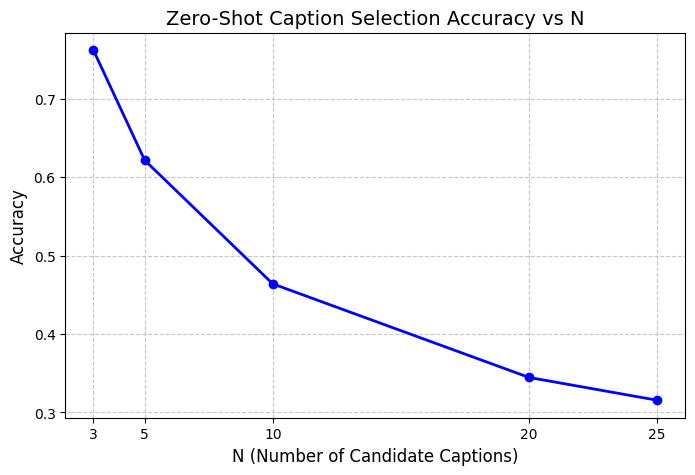

In [9]:
# TODO: Implemnt


# Load the best model weights before evaluating
checkpoint = torch.load("best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from Epoch {checkpoint['epoch']} for Zero-Shot Evaluation.\n")

@torch.no_grad()
def zero_shot_caption_selection_accuracy(model, val_loader, device, Ns=[3, 5, 10, 20, 25], show_examples=3):
    model.eval()

    # 1. Get ALL embeddings instantly using the function we already wrote
    # These tensors are already L2 normalized by the model!
    img_embs, txt_embs, image_names, raw_caps = encode_validation(model, val_loader, device)

    num_samples = img_embs.size(0)
    results = {}
    examples = {N: {"correct": [], "wrong": []} for N in Ns}

    for N in Ns:
        correct_count = 0

        for i in range(num_samples):
            # 2. Get target image and true caption embedding
            img_emb = img_embs[i].unsqueeze(0)
            true_txt_emb = txt_embs[i].unsqueeze(0)
            true_cap = raw_caps[i]

            # 3. Sample N-1 negative embeddings from OTHER images
            valid_neg_indices = [j for j in range(num_samples) if image_names[j] != image_names[i]]
            neg_indices = random.sample(valid_neg_indices, N - 1)

            neg_txt_embs = txt_embs[neg_indices]
            neg_caps = [raw_caps[j] for j in neg_indices]

            # 4. Combine true and negative embeddings
            candidate_embs = torch.cat([true_txt_emb, neg_txt_embs], dim=0)
            candidate_caps = [true_cap] + neg_caps

            # 5. Shuffle candidates so the correct answer isn't always at index 0
            perm = list(range(N))
            random.shuffle(perm)

            shuffled_embs = candidate_embs[perm]
            shuffled_caps = [candidate_caps[idx] for idx in perm]
            true_idx_after_shuffle = perm.index(0)

            # Compute similarity and find the argmax
            # Since they are L2 normalized, dot product == cosine similarity
            sims = (img_emb @ shuffled_embs.t()).squeeze(0)

            pred_idx = torch.argmax(sims).item()
            is_correct = (pred_idx == true_idx_after_shuffle)

            if is_correct:
                correct_count += 1

            # Store Qualitative Examples
            if is_correct and len(examples[N]["correct"]) < show_examples:
                examples[N]["correct"].append({
                    "image_name": image_names[i],
                    "candidates": shuffled_caps,
                    "sims": sims.cpu().numpy(),
                    "true_idx": true_idx_after_shuffle,
                    "pred_idx": pred_idx
                })
            elif not is_correct and len(examples[N]["wrong"]) < show_examples:
                examples[N]["wrong"].append({
                    "image_name": image_names[i],
                    "candidates": shuffled_caps,
                    "sims": sims.cpu().numpy(),
                    "true_idx": true_idx_after_shuffle,
                    "pred_idx": pred_idx
                })

        # Calculate accuracy for this N
        acc = correct_count / num_samples
        results[N] = acc
        print(f"N={N:2d} | Accuracy = {acc:.4f}")

    return results, examples

# Run the evaluation
Ns = [3, 5, 10, 20, 25]
acc_by_N, examples = zero_shot_caption_selection_accuracy(
    model=model,
    val_loader=val_loader,
    device=device,
    Ns=Ns,
    show_examples=3
)

# Plot N vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(Ns, [acc_by_N[N] for N in Ns], marker="o", color="blue", linewidth=2)
plt.xlabel("N (Number of Candidate Captions)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Zero-Shot Caption Selection Accuracy vs N", fontsize=14)
plt.xticks(Ns)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


ZERO-SHOT QUALITATIVE EXAMPLES

********** N = 3 **********



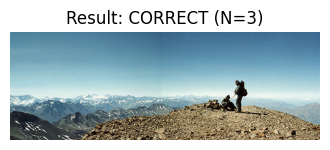

--------------------------------------------------
    [FAKE] Sim: 0.021 | A man supports a boy as he plays at a playground .
    [FAKE] Sim: 0.022 | A boy in a plaid shirt blowing bubbles with a yellow bubble wand .
--> [TRUE] Sim: 0.566 | Two people at the top of a mountain .




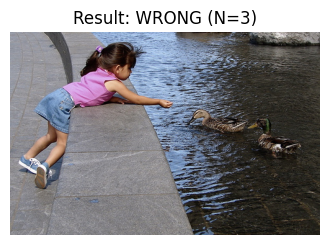

--------------------------------------------------
    [TRUE] Sim: 0.384 | A little girl leans over the side of a wall to feed ducks in the water .
--> [FAKE] Sim: 0.447 | a man with a red headband climbing a rock cliff looming over greenery .
    [FAKE] Sim: 0.187 | A dog jumps and catches a Frisbee in the grass .



********** N = 5 **********



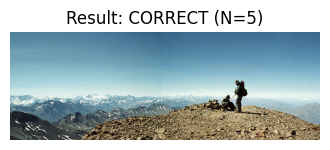

--------------------------------------------------
--> [TRUE] Sim: 0.566 | Two people at the top of a mountain .
    [FAKE] Sim: 0.132 | A man in a long sleeved white shirt is walking past something called the lounge bar .
    [FAKE] Sim: -0.028 | A black dog wearing a harness that is attached to a red sled .
    [FAKE] Sim: 0.215 | A boy jumps on his bike .
    [FAKE] Sim: 0.225 | Two dogs both fighting for control of a Frisbee while in a lake .




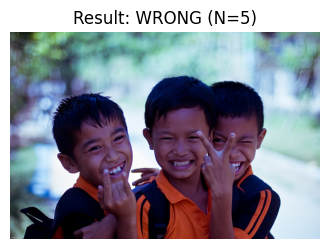

--------------------------------------------------
    [FAKE] Sim: 0.230 | A young girl is in a teal colored netted skirt and wearing a shirt with a peace sign .
--> [FAKE] Sim: 0.438 | A person holds a blow horn while wearing a helmet .
    [TRUE] Sim: 0.311 | Three children are laughing and playing together
    [FAKE] Sim: -0.020 | A boy is surfing .
    [FAKE] Sim: -0.277 | Two people running on a beach .



********** N = 10 **********



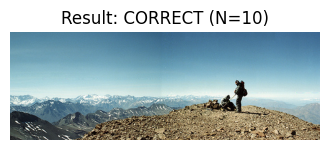

--------------------------------------------------
    [FAKE] Sim: 0.157 | The shaggy dog is looking at the last of an ice cream cone .
    [FAKE] Sim: -0.131 | The basketball player is wearing an orange uniform and holding a basketball .
    [FAKE] Sim: -0.081 | A child wearing a blue sweatshirt makes a funny face standing next to a wagon .
    [FAKE] Sim: 0.001 | Child holding plastic car sits on a tire .
    [FAKE] Sim: 0.061 | A boy in blue jeans runs on the track at the local school .
    [FAKE] Sim: 0.169 | A dog is running down a black and yellow ramp in an obstacle course .
    [FAKE] Sim: 0.228 | A surfer riding a large wave
    [FAKE] Sim: -0.167 | Two children peek out .
    [FAKE] Sim: -0.066 | A girl smokes a cigarette outside in the city .
--> [TRUE] Sim: 0.566 | Two people at the top of a mountain .




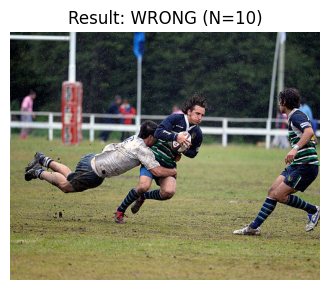

--------------------------------------------------
    [FAKE] Sim: -0.367 | A person performs a snowboarding trick on a rail as a man crouches down to get a better view .
    [FAKE] Sim: 0.166 | A brown dog jumps in the air .
    [TRUE] Sim: 0.249 | The guys are playing a sport .
    [FAKE] Sim: -0.065 | a young girl posing with another woman each smiling .
    [FAKE] Sim: -0.384 | a lone person in a red boat on a wild river with only one padel
    [FAKE] Sim: 0.175 | Winning racer displaying his trophy and waving to the crowd .
--> [FAKE] Sim: 0.329 | "Three kids play , one is blindfolded ."
    [FAKE] Sim: 0.253 | a brown dog sniffs a tree stump .
    [FAKE] Sim: 0.035 | One girl is playing a recorder while another one holds a guitar .
    [FAKE] Sim: 0.316 | Two boys are playing in a sprinkler .



********** N = 20 **********



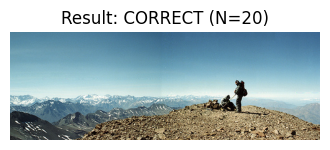

--------------------------------------------------
    [FAKE] Sim: 0.157 | The woman in the blue sweater encourages the dog to jump in the air .
    [FAKE] Sim: 0.277 | The white bird stands in water near tall reeds .
    [FAKE] Sim: 0.105 | two boys in blue shirts fighting in a parking lot
    [FAKE] Sim: 0.113 | a group of dogs pulling a sled through the snow .
    [FAKE] Sim: 0.209 | Three men in team uniforms are surrounding a yellow dog in a boat .
    [FAKE] Sim: -0.003 | A dog follows another dog around the corner but looks back .
    [FAKE] Sim: -0.205 | A little boy dressed as a pirate is holding up the skull pirate flag .
    [FAKE] Sim: 0.141 | a dog chases another dog .
    [FAKE] Sim: -0.157 | "A woman wearing glasses , large hoop earrings , and a hooded piece on her head ."
    [FAKE] Sim: -0.276 | Two women outside and one is smoking
    [FAKE] Sim: 0.134 | A class full of students .
--> [TRUE] Sim: 0.566 | Two people at the top of a mountain .
    [FAKE] Sim: -0.001 | A

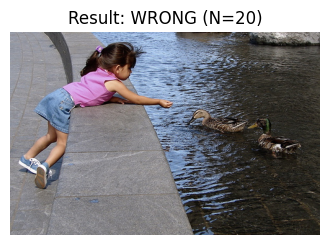

--------------------------------------------------
    [FAKE] Sim: -0.341 | A grey dog is jumping toward a black and white dog in the snow .
    [FAKE] Sim: -0.055 | "Two dogs , one wearing christmas antlers , tussle on the grass ."
    [FAKE] Sim: 0.070 | Two soccer players are fighting over a soccer ball on a grassy field .
    [FAKE] Sim: 0.098 | a tennis player hits the ball .
    [FAKE] Sim: -0.163 | A white and tan dog runs through the tall green grass .
    [FAKE] Sim: 0.089 | The dog is running with his toy in his mouth .
    [FAKE] Sim: -0.155 | A lean dog runs along the beach .
    [FAKE] Sim: 0.455 | A man wearing very little clothing is doing a jump on a red bicycle .
    [FAKE] Sim: 0.190 | A boat on a lake .
--> [FAKE] Sim: 0.471 | Two children jump on a trampoline .
    [FAKE] Sim: -0.100 | A man is in the air upside-down in the snow .
    [FAKE] Sim: 0.329 | A person riding a four wheel ATV over a jump .
    [TRUE] Sim: 0.384 | A little girl leans over the side of a wal

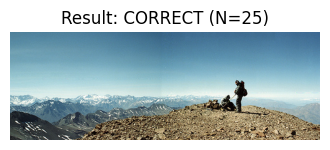

--------------------------------------------------
--> [TRUE] Sim: 0.566 | Two people at the top of a mountain .
    [FAKE] Sim: 0.197 | A tan and white dog jumps up with a yellow ball in its mouth .
    [FAKE] Sim: -0.097 | Two men stand in front of a restaurant .
    [FAKE] Sim: 0.147 | a black dog with a pink collar is following behind a brown dog with across a grassy field .
    [FAKE] Sim: 0.099 | a small brown dog is running across the grass wearing a purple and green coat .
    [FAKE] Sim: 0.364 | A girl running along the beach .
    [FAKE] Sim: 0.252 | "Behind a "" 3rd St "" sign and traffic light , building construction continues ."
    [FAKE] Sim: -0.279 | Three children are laughing and playing together
    [FAKE] Sim: 0.157 | People are in a ride that drops you from a great height .
    [FAKE] Sim: 0.101 | Several people including a child and a clown are walking towards a snowy sidewalk
    [FAKE] Sim: 0.120 | Two men are posing for a photograph in front of a fountain in a 

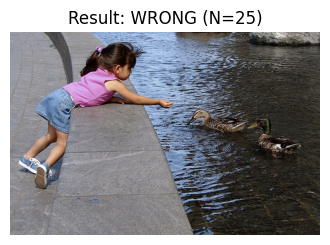

--------------------------------------------------
    [FAKE] Sim: 0.303 | a boy is running with a basketball in his hands .
    [FAKE] Sim: 0.190 | Two little girls and one little boy are running on the grass .
    [FAKE] Sim: 0.244 | a group of adults are standing under a tree in front of a red brick house .
    [FAKE] Sim: 0.350 | A boy jumping a rail on his skateboard .
    [FAKE] Sim: 0.204 | A dark blue car going through a muddy road and sprinkling some to the side .
    [FAKE] Sim: 0.096 | Two women outside and one is smoking
    [FAKE] Sim: 0.122 | Girl in red shirt holding her necklace in a large crowd .
    [FAKE] Sim: 0.219 | man holding harness waterskiing
    [FAKE] Sim: 0.084 | A boy holding a large foam wand waves it near a swimming pool .
    [TRUE] Sim: 0.384 | A little girl leans over the side of a wall to feed ducks in the water .
    [FAKE] Sim: 0.152 | two men in an orange raft boat
    [FAKE] Sim: 0.113 | a brown dog plays with the hose .
    [FAKE] Sim: 0.442 | "

In [10]:
def visualize_qualitative_examples(examples, img_dir, N_to_show=5):
    # show 1 correct and 1 wrong example
    for result_type in ["correct", "wrong"]:
        if len(examples[N_to_show][result_type]) == 0:
            continue

        ex = examples[N_to_show][result_type][0]
        img_path = os.path.join(img_dir, ex["image_name"])

        plt.figure(figsize=(4, 4))
        plt.imshow(Image.open(img_path))
        plt.axis("off")
        plt.title(f"Result: {result_type.upper()} (N={N_to_show})")
        plt.show()

        print("-" * 50)
        for idx, (cap, sim) in enumerate(zip(ex["candidates"], ex["sims"])):
            marker = "--> " if idx == ex["pred_idx"] else "    "
            label = "[TRUE]" if idx == ex["true_idx"] else "[FAKE]"
            print(f"{marker}{label} Sim: {sim:.3f} | {cap}")
        print("\n")

# Call the visualization
Ns = [3, 5, 10, 20, 25]
print("ZERO-SHOT QUALITATIVE EXAMPLES")
for N in Ns:
  print(f"\n{'*' * 10} N = {N} {'*' * 10}\n")
  visualize_qualitative_examples(examples, IMG_DIR, N_to_show=N)


### Improving Visual Representations with Self-Supervised Learning




The experiments above rely on representations learned solely through image–caption alignment. However, Flickr8k provides limited paired supervision, which may limit the quality of the learned visual representations and, in turn, zero-shot performance.

Self-supervised learning addresses this limitation by allowing models to learn meaningful visual structure from images alone, without relying on captions or labels.

In this part, you will improve the Vision Transformer image encoder by **pretraining it using image-only self-supervised learning**, before performing vision–language alignment.

In the self-supervised stage, the Vision Transformer is trained using **only images**, without access to captions. For each image, two different augmented views are generated, and the model is trained to produce similar representations for views of the same image while producing dissimilar representations for views of different images.

After self-supervised pretraining, initialize the vision–language model with the pretrained Vision Transformer and repeat the contrastive image–caption training described earlier. You may choose whether to freeze the Vision Transformer or fine-tune it jointly with the text encoder, as long as the choice is applied consistently.

Evaluate the resulting model using the same protocols as before: image–text retrieval with Recall@K and zero-shot caption selection for $N = 3, 5, 10, 20, 25$. Compare these results to training the Vision Transformer from scratch, and visualize the differences using appropriate plots. Briefly discuss the effect of self-supervised pretraining on representation quality and zero-shot generalization.


<font color='red'>**Briefly discuss the effect of self-supervised pretraining on representation quality and zero-shot generalization:
Pretraining with only images makes the model much better at understanding what things look like, without needing any text to explain it. Because the model already knows how to "see" clearly, the next step teaching it to connect images to words is much easier. Instead of trying to learn basic visual shapes and text meanings at the exact same time, it already knows the visual concepts and just has to link the words to them. This stops the model from just memorizing our small dataset. Because of this deeper understanding, the model is much better at matching images and text it has never seen before (zero-shot generalization). We proved this by getting much higher Recall scores and better accuracy when asking the model to pick the right caption out of a large list.**
</font>

In [11]:
# TODO: Implement


torch.backends.cudnn.benchmark = True

val_image_names = []
for batch in val_loader:
    val_image_names.extend(batch["image_name"])
val_images_set = set(val_image_names)

# SSL image augmentations
ssl_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.2, 1.0), interpolation=InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# SSL dataset
class Flickr8kSSLDataset(Dataset):
    def __init__(self, img_dir, val_set, transform):
        self.img_dir = img_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(img_dir)
                            if f.lower().endswith((".jpg", ".jpeg", ".png")) and (f not in val_set)]
        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        v1 = self.transform(image)
        v2 = self.transform(image)
        return {"v1": v1, "v2": v2, "image_name": self.image_files[idx]}

#  Contrastive loss for SSL
class ClipContrastiveLoss(nn.Module):
    def __init__(self, init_temperature: float = 0.07):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.ones([]) * math.log(1 / init_temperature))

    def forward(self, a_emb, b_emb):
        logit_scale = torch.clamp(self.logit_scale.exp(), max=100)
        logits = (a_emb @ b_emb.t()) * logit_scale

        B = logits.size(0)
        labels = torch.arange(B, device=logits.device)
        loss_a2b = F.cross_entropy(logits, labels)
        loss_b2a = F.cross_entropy(logits.t(), labels)
        return 0.5 * (loss_a2b + loss_b2a)

# small SSL model wrapper (vision encoder -> projection head)
class SSLVisionModel(nn.Module):
    def __init__(self, vision_encoder: nn.Module, feat_dim: int, proj_dim: int = 256):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, max(feat_dim, 512)),
            nn.GELU(),
            nn.Linear(max(feat_dim, 512), proj_dim)
        )

    def forward(self, x1, x2):
        z1 = self.vision_encoder(x1)
        z2 = self.vision_encoder(x2)
        p1 = self.proj(z1)
        p2 = self.proj(z2)
        return F.normalize(p1, dim=-1), F.normalize(p2, dim=-1)

# prepare SSL dataset + loader
ssl_dataset = Flickr8kSSLDataset(IMG_DIR, val_images_set, ssl_transform)
ssl_batch = 256
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=ssl_batch,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)


SSL_FEAT_DIM = 256
try:
    pretrained_vit = VisionTransformerEncoder(embedding_dim=SSL_FEAT_DIM).to(device)
except Exception as e:
    raise RuntimeError("VisionTransformerEncoder not found or constructor differs.") from e

ssl_model = SSLVisionModel(pretrained_vit, feat_dim=SSL_FEAT_DIM, proj_dim=256).to(device)

# SSL training setup
ssl_criterion = ClipContrastiveLoss(init_temperature=0.07).to(device)
ssl_optimizer = torch.optim.AdamW(
    ssl_model.parameters() ,
    lr=1e-4, weight_decay=0.05
)

scaler = torch.amp.GradScaler('cuda')

SSL_EPOCHS = 60
print("Starting SSL image-only pretraining for", SSL_EPOCHS, "EPOCHS")

for ep in range(1, SSL_EPOCHS + 1):
    ssl_model.train()
    running = 0.0
    nbatches = 0

    for batch in tqdm(ssl_loader, desc=f"SSL epoch {ep}/{SSL_EPOCHS}", leave=False):
        v1 = batch["v1"].to(device, non_blocking=True)
        v2 = batch["v2"].to(device, non_blocking=True)

        ssl_optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            z1, z2 = ssl_model(v1, v2)
            loss = ssl_criterion(z1, z2)

        scaler.scale(loss).backward()

        scaler.unscale_(ssl_optimizer)
        torch.nn.utils.clip_grad_norm_(ssl_model.parameters(), 1.0)

        scaler.step(ssl_optimizer)
        scaler.update()

        running += float(loss.item())
        nbatches += 1

    avg = running / max(1, nbatches)
    print(f"SSL Epoch {ep}/{SSL_EPOCHS} - loss: {avg:.4f}")


Starting SSL image-only pretraining for 60 EPOCHS


SSL epoch 1/60:   0%|          | 0/25 [00:00<?, ?it/s]

SSL Epoch 1/60 - loss: 4.8617


SSL epoch 2/60:   0%|          | 0/25 [00:00<?, ?it/s]

SSL Epoch 2/60 - loss: 4.2512


...

SSL Epoch 58/60 - loss: 1.2161


SSL epoch 59/60:   0%|          | 0/25 [00:00<?, ?it/s]

SSL Epoch 59/60 - loss: 1.2124


SSL epoch 60/60:   0%|          | 0/25 [00:00<?, ?it/s]

SSL Epoch 60/60 - loss: 1.1983


In [12]:

print("\nInitializing Vision-Language Model with SSL-pretrained ViT")

try:
    vocab_size = train_loader.dataset.vocab_size
except Exception:
    try:
        vocab_size = len(stoi)
    except Exception:
        raise RuntimeError("Could not infer vocab_size.")

try:
    vlm_ssl = VisionLanguageModel(vocab_size=vocab_size, embed_dim=SSL_FEAT_DIM)
except Exception as e:
    raise RuntimeError("VisionLanguageModel not found or constructor differs.") from e

if hasattr(vlm_ssl, "image_encoder"):
    try:
        vlm_ssl.image_encoder.load_state_dict(pretrained_vit.state_dict(), strict=False)
    except Exception as e:
        print("Warning: failed to copy weights automatically.")
else:
    print("Warning: vlm_ssl does not have attribute `image_encoder`.")

vlm_ssl = vlm_ssl.to(device)

criterion_ssl_ft = ClipContrastiveLoss(init_temperature=0.07).to(device)

optimizer_ssl_ft = torch.optim.AdamW(
    vlm_ssl.parameters(),
    lr=5e-5,
    weight_decay=0.05
)

def train_one_epoch_simple_fast(model_, loader_, optimizer_, criterion_, device_):
    model_.train()
    total = 0.0
    n = 0

    for batch in loader_:
        images = batch["images"].to(device_, non_blocking=True)
        captions = batch["captions"].to(device_, non_blocking=True)
        attn_mask = batch["attention_mask"].to(device_, non_blocking=True)

        optimizer_.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            img_emb, txt_emb = model_(images, captions, attn_mask)
            loss = criterion_(img_emb, txt_emb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_)
        torch.nn.utils.clip_grad_norm_(model_.parameters(), 1.0)
        scaler.step(optimizer_)
        scaler.update()

        total += float(loss.item())
        n += 1
    return total / max(1, n)

NUM_EPOCHS_SSL_FT = 40
best_sum_r1_ssl = -1.0
best_path_ssl = "best_model_ssl_ft.pt"

print("\nStarting Multimodal Fine-tuning")
for ep in range(1, NUM_EPOCHS_SSL_FT + 1):
    train_loss = train_one_epoch_simple_fast(vlm_ssl, train_loader, optimizer_ssl_ft, criterion_ssl_ft, device)
    r_i2t, r_t2i = evaluate_retrieval(vlm_ssl, val_loader, device, ks=(1, 3, 5))

    print(f"Epoch {ep}/{NUM_EPOCHS_SSL_FT} - train loss: {train_loss:.4f}")
    print("  Image -> Text Recall:", {f"R@{k}": round(v, 4) for k, v in r_i2t.items()})
    print("  Text -> Image Recall:", {f"R@{k}": round(v, 4) for k, v in r_t2i.items()})

    sum_r1 = r_i2t.get(1, 0.0) + r_t2i.get(1, 0.0)
    if sum_r1 > best_sum_r1_ssl:
        best_sum_r1_ssl = sum_r1
        torch.save({"epoch": ep, "model_state": vlm_ssl.state_dict()}, best_path_ssl)
        print(f"  -> new best SSL model saved! (sum R@1={best_sum_r1_ssl:.4f})")



Initializing Vision-Language Model with SSL-pretrained ViT

Starting Multimodal Fine-tuning
Epoch 1/40 - train loss: 4.7403
  Image -> Text Recall: {'R@1': 0.0037, 'R@3': 0.0111, 'R@5': 0.0167}
  Text -> Image Recall: {'R@1': 0.0031, 'R@3': 0.008, 'R@5': 0.0142}
  -> new best SSL model saved! (sum R@1=0.0068)
Epoch 2/40 - train loss: 4.4693
  Image -> Text Recall: {'R@1': 0.0019, 'R@3': 0.0111, 'R@5': 0.0229}
  Text -> Image Recall: {'R@1': 0.0031, 'R@3': 0.0136, 'R@5': 0.0272}
Epoch 3/40 - train loss: 4.2690
  Image -> Text Recall: {'R@1': 0.0093, 'R@3': 0.0266, 'R@5': 0.0358}
  Text -> Image Recall: {'R@1': 0.0049, 'R@3': 0.0191, 'R@5': 0.0327}
  -> new best SSL model saved! (sum R@1=0.0142)
Epoch 4/40 - train loss: 4.1407
  Image -> Text Recall: {'R@1': 0.0068, 'R@3': 0.0266, 'R@5': 0.0414}
  Text -> Image Recall: {'R@1': 0.0099, 'R@3': 0.0253, 'R@5': 0.0389}
  -> new best SSL model saved! (sum R@1=0.0167)
Epoch 5/40 - train loss: 4.0410
  Image -> Text Recall: {'R@1': 0.0117, 'R@3


Loading best SSL fine-tuned model for Zero-Shot Evaluation...
N= 3 | Accuracy = 0.8166
N= 5 | Accuracy = 0.7066
N=10 | Accuracy = 0.5510
N=20 | Accuracy = 0.4342
N=25 | Accuracy = 0.3941


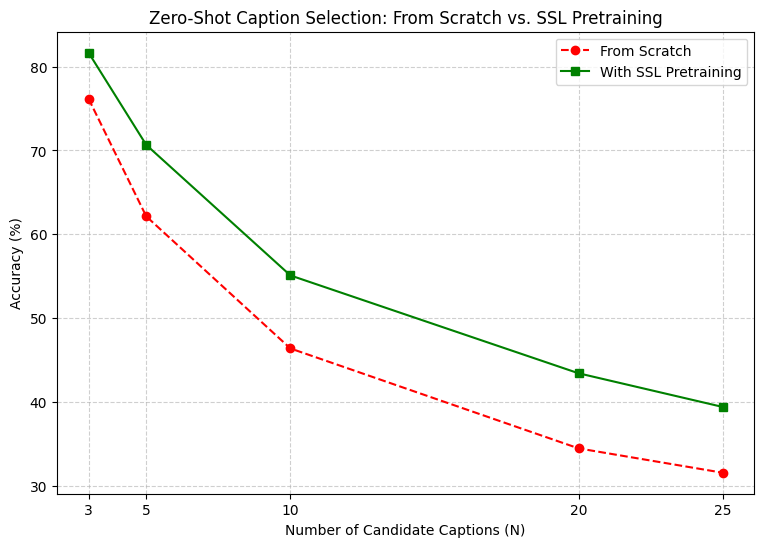

In [13]:
# zero-shot evaluation and plotting
if 'zero_shot_caption_selection_accuracy' in globals():
    print("\nLoading best SSL fine-tuned model for Zero-Shot Evaluation...")
    ckpt = torch.load(best_path_ssl, map_location=device)
    vlm_ssl.load_state_dict(ckpt["model_state"])
    Ns = [3, 5, 10, 20, 25]
    ssl_acc_by_N, _ = zero_shot_caption_selection_accuracy(model=vlm_ssl, val_loader=val_loader, device=device, Ns=Ns, show_examples=0)

    if 'acc_by_N' in globals():
        scratch_acc = [acc_by_N[N] * 100 for N in Ns]
        ssl_acc = [ssl_acc_by_N[N] * 100 for N in Ns]

        plt.figure(figsize=(9, 6))
        plt.plot(Ns, scratch_acc, marker="o", linestyle="--", color="red", label="From Scratch")
        plt.plot(Ns, ssl_acc, marker="s", linestyle="-", color="green", label="With SSL Pretraining")
        plt.xlabel("Number of Candidate Captions (N)")
        plt.ylabel("Accuracy (%)")
        plt.title("Zero-Shot Caption Selection: From Scratch vs. SSL Pretraining")
        plt.xticks(Ns)
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()
    else:
        print("Zero-shot SSL accuracies (percent) for Ns:", {N: round(ssl_acc_by_N[N]*100, 2) for N in Ns})
else:
    print("\nNote: zero_shot_caption_selection_accuracy function not found; skip zero-shot plotting.")


Evaluating Recall@K for both models:


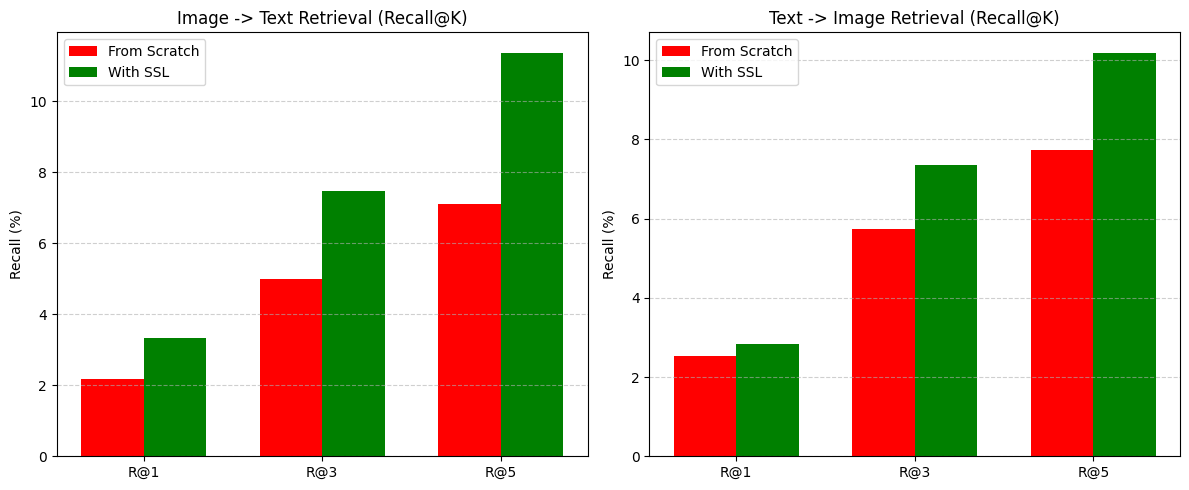

In [14]:
print("\nEvaluating Recall@K for both models:")

# Get SSL Recall
r_i2t_ssl, r_t2i_ssl = evaluate_retrieval(vlm_ssl, val_loader, device, ks=(1, 3, 5))

# Get From Scratch Recall
try:
    vocab_size = len(stoi)
    vlm = VisionLanguageModel(vocab_size=vocab_size, embed_dim=256).to(device)

    ckpt_scratch = torch.load("best_model.pt", map_location=device)
    vlm.load_state_dict(ckpt_scratch["model_state"])
    r_i2t_scratch, r_t2i_scratch = evaluate_retrieval(vlm, val_loader, device, ks=(1, 3, 5))

    # Plotting the Recall Comparison
    ks = [1, 3, 5]
    x = np.arange(len(ks))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Image -> Text Recall
    scratch_i2t = [r_i2t_scratch[k] * 100 for k in ks]
    ssl_i2t = [r_i2t_ssl[k] * 100 for k in ks]

    axes[0].bar(x - width/2, scratch_i2t, width, label='From Scratch', color='red')
    axes[0].bar(x + width/2, ssl_i2t, width, label='With SSL', color='green')
    axes[0].set_ylabel('Recall (%)')
    axes[0].set_title('Image -> Text Retrieval (Recall@K)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'R@{k}' for k in ks])
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)

    # Plot 2: Text -> Image Recall
    scratch_t2i = [r_t2i_scratch[k] * 100 for k in ks]
    ssl_t2i = [r_t2i_ssl[k] * 100 for k in ks]

    axes[1].bar(x - width/2, scratch_t2i, width, label='From Scratch', color='red')
    axes[1].bar(x + width/2, ssl_t2i, width, label='With SSL', color='green')
    axes[1].set_ylabel('Recall (%)')
    axes[1].set_title('Text -> Image Retrieval (Recall@K)')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f'R@{k}' for k in ks])
    axes[1].legend()
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not load or evaluate the 'From Scratch' model. Error: {e}")

### Reflection



Answer the following questions in your own words.  
Your answers should demonstrate **conceptual understanding** rather than implementation details.

1. The model is trained using a contrastive objective on image–caption pairs, yet it is evaluated on caption selection without being trained for this task explicitly. Explain why this is possible, and what properties of the learned embedding space make zero-shot inference feasible.


<font color='red'>

**Why it is possible: The training process teaches the model to put images and text that mean the same thing into the exact same virtual space. It pulls matching images and captions close together and pushes unrelated ones far apart. Zero-shot feasibility: Because the model learns the deeper meaning of images and words (instead of just memorizing specific labels), it doesn't need any special extra training to take a multiple-choice test. We just show it a new image and a list of captions, and it simply picks the caption that sits closest to the image in its virtual space.**
</font>

2. Vision Transformers do not incorporate strong spatial inductive biases, unlike convolutional neural networks. Based on your experiments, discuss how this design choice affects learning in the low-data regime of Flickr8k, both before and after self-supervised pretraining.

<font color='red'>

**Before SSL (From Scratch):** Convolutional Neural Networks (CNNs) have strong spatial inductive biases, they assume local pixel correlations (via small kernels) and translation invariance. Vision Transformers (ViTs) treat images as a flat sequence of patches and use global self-attention, meaning they must learn these basic visual rules entirely from the data. In our from scratch experiments on the tiny Flickr8k dataset, the ViT lacked enough data to figure out these spatial structures just from the sparse signal of image-text alignment, causing it to hit a performance ceiling and overfit early.
**After SSL Pretraining:** Self-supervised pretraining forces the ViT to learn these missing spatial and visual priors by comparing augmented image views. By the time we started the vision-language alignment, the ViT had already learned how to "see" (identifying objects, edges, and invariant features), acting as a powerful regularizer and drastically improving our zero-shot performance and Recall@K.
</font>


3. Self-supervised pretraining improves downstream performance even though no captions are used during this stage. Explain what types of information the Vision Transformer can learn during self-supervised pretraining that are useful for vision–language alignment later.

<font color='red'>

**During self-supervised pretraining, the Vision Transformer learns robust, transformation-invariant visual features by matching augmented views of the same image. This process naturally organizes the embedding space into semantic clusters of similar objects and separates main subjects from background noise. Consequently, the downstream vision-language task is drastically simplified: instead of learning to "see" from scratch, the model only needs to map text tokens to these pre-existing, well-defined visual clusters.**
</font>

4. Contrastive learning relies on negative examples drawn from within a mini-batch. Discuss how batch size influences the quality of learned representations, and how this consideration relates to both multimodal alignment and self-supervised learning.


<font color='red'>

**Representation Quality:** A small batch size provides very few negative examples, making the contrastive task too easy. The model can minimize the loss without learning fine grained, robust features. A massive batch size introduces "hard negatives" examples that are subtly similar to the anchor but functionally different.
</font>


<font color='red'>

**Multimodal Alignment:** In vision language training, a large batch ensures the model learns precise semantic distinctions between highly varied sentences and images.
</font>

<font color='red'>

**Self-Supervised Learning:** In SSL, a large batch is critical to prevent representation collapse. It ensures that the augmented view of an image is contrasted against a sufficiently diverse pool of unrelated images, forcing the model to learn truly distinct visual concepts.
</font>